<a href="https://colab.research.google.com/github/fadakarg-ui/CSI-Indoor-Localization-MLP/blob/main/EE559_Project_Codes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
# =============================================================================
# Core Scientific Libraries for Data Manipulation and Numerical Operations
# =============================================================================
import numpy as np        # Fundamental package for numerical operations, especially with arrays and matrices.
import pandas as pd       # Powerful library for data manipulation and analysis, primarily with DataFrames.
import scipy.io as sio    # Used for reading and writing MATLAB .mat files, essential for loading datasets.
import h5py               # Library for interacting with HDF5 files, often used for large datasets like .mat v7.3.

# =============================================================================
# Deep Learning Frameworks and Utilities
# =============================================================================
import torch              # Primary PyTorch library for building and training neural networks.
import torch.nn as nn     # Neural network modules and layers (e.g., Linear, ReLU, BatchNorm).
import torch.optim as optim # Optimization algorithms (e.g., Adam, SGD) for training models.
from torch.utils.data import TensorDataset, DataLoader # Utilities for efficient data handling and batching.

# =============================================================================
# Machine Learning Utilities for Data Preparation
# =============================================================================
from sklearn.model_selection import train_test_split # Function to split data into training, validation, and test sets.

# =============================================================================
# Plotting and Visualization Libraries
# =============================================================================
import matplotlib.pyplot as plt # Comprehensive library for creating static, animated, and interactive visualizations.

# =============================================================================
# System and Memory Management Utilities
# =============================================================================
from google.colab import drive # Specific utility for Google Colab to mount Google Drive.
import os                     # Provides a way of using operating system dependent functionality (e.g., file paths).
import gc                     # Interface to the garbage collector, useful for explicit memory management.

In [2]:
pip install matplot2tikz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 1.8 MB/s eta 0:00:00


In [3]:
# =============================================================================
# External Package
# =============================================================================
from matplot2tikz import save as save_tikz  # For converting Matplotlib figures to TikZ/PGFPlots for LaTeX documents.

In [4]:
# =============================================================================
# Machine Learning Libraries for Baseline Models
# These are used for comparison against the proposed MLP method, which is
# implemented from scratch in pure NumPy.
# =============================================================================
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Load Data

In [5]:
# ==========================================
# 1. Mount Google Drive
# ==========================================
print("Mounting Google Drive...")
drive.mount('/content/drive')

Mounting Google Drive...
Mounted at /content/drive


In [6]:
# ==========================================
# 3. Smart & Memory-Efficient Loader
# ==========================================
# Define your paths (update these if your folder structure is different)
# We use the WiLoc dataset from the IEEE INFOCOM paper "WiLoc: Massive Measured Dataset of Wi-Fi Channel State Information with Application to Machine-Learning Based Localization".
# The dataset link is provided in that paper at "https://forms.gle/8Z1zUVeF9ssfKR4r9".
# Due to richer dataset samples, we use the Building2 subset of data, but all methodologies are still applicable for other buildings yielding similar results.
BASE_PATH = '/content/drive/MyDrive/WiLoc_Data'
CSI_FILE = os.path.join(BASE_PATH, 'Building2_CSI.mat')
META_FILE = os.path.join(BASE_PATH, 'Building2_Metadata.mat')

print("\n--- Loading Dataset ---")

def load_mat_efficiently(filepath, key):
    """Loads massive .mat files efficiently, falling back to scipy if older format."""
    try:
        # Attempt to load using h5py (for MATLAB v7.3+ files)
        f = h5py.File(filepath, 'r')
        print(f" -> Loading '{key}' with h5py (v7.3 format)...")

        if key == 'CSI':
            # Process CSI data: calculate magnitude from real and imaginary parts
            real_part = np.array(f[key]['real']).T.astype(np.float32)
            imag_part = np.array(f[key]['imag']).T.astype(np.float32)
            data = np.sqrt(real_part**2 + imag_part**2, dtype=np.float32)
            del real_part, imag_part # Free up memory immediately
            gc.collect()
        else:
            # Load other metadata directly
            data = np.array(f[key]).T.astype(np.float32)

        f.close()
        return data

    except OSError:
        # Fallback to scipy.io for older MATLAB .mat file formats
        print(f" -> Loading '{key}' with scipy.io (Older format)...")
        mat_data = sio.loadmat(filepath)[key]

        if key == 'CSI':
            # Calculate magnitude for CSI data
            data = np.abs(mat_data).astype(np.float32)
        else:
            # Load other metadata
            data = mat_data.astype(np.float32)

        return data

try:
    # Load metadata and CSI magnitude data
    metadata = load_mat_efficiently(META_FILE, 'Metadata')
    csi_magnitude = load_mat_efficiently(CSI_FILE, 'CSI')
    print("Data loaded and RAM optimized successfully!")

except Exception as e:
    print(f"Error loading files: {e}")
    raise



--- Loading Dataset ---
 -> Loading 'Metadata' with scipy.io (Older format)...
 -> Loading 'CSI' with h5py (v7.3 format)...
Data loaded and RAM optimized successfully!


In [7]:
print(f"Metadata size: {os.path.getsize(META_FILE) / (1024*1024):.2f} MB")
print(f"CSI size: {os.path.getsize(CSI_FILE) / (1024*1024):.2f} MB")

Metadata size: 106.87 MB
CSI size: 2253.43 MB


In [8]:
# Configuration
USE_CSI = True
GRID_SIZE = 0.5   # Group measurements within 1.0 meter blocks
MAX_APS = 60      # Keep the top 30 most frequently heard physical APs

In [9]:
# ==========================================
# 3. Spatial Fingerprinting (Multi-AP Grouping)
# ==========================================
print(f"\n--- Constructing Multi-AP Fingerprints (Grid: {GRID_SIZE}m) ---")

# Extract relevant columns
X_raw = metadata[:, 6]
Y_raw = metadata[:, 7]
# AP label format is A + N/10. np.floor gets the physical AP integer (A)
AP_raw = np.floor(metadata[:, 5])

# Create a DataFrame to handle grouping logic easily
df = pd.DataFrame({
    'Row_Idx': np.arange(len(X_raw)),
    'X': X_raw,
    'Y': Y_raw,
    'AP': AP_raw
})

# Drop invalid coordinates
df = df.dropna(subset=['X', 'Y'])

# Discretize locations into a Grid to group nearby measurements
df['Grid_X'] = (df['X'] / GRID_SIZE).round() * GRID_SIZE
df['Grid_Y'] = (df['Y'] / GRID_SIZE).round() * GRID_SIZE
df['Grid_ID'] = df['Grid_X'].astype(str) + "_" + df['Grid_Y'].astype(str)

# Identify the most universally heard APs in this building to form our feature vector
top_aps = df['AP'].value_counts().nlargest(MAX_APS).index.tolist()
print(f"Tracking top {MAX_APS} APs: {top_aps[:5]}...")

# Filter dataset to only include these top APs
df_top = df[df['AP'].isin(top_aps)]

# Build the new grouped dataset
grouped = df_top.groupby('Grid_ID')
N_freq = csi_magnitude.shape[1] if USE_CSI else 1

X_grouped = []
Y_grouped = []

for grid_id, group in grouped:
    # 1. Target coordinate is the true mean (X,Y) of all points inside this grid cell
    target_x = group['X'].mean()
    target_y = group['Y'].mean()

    # 2. Initialize a blank feature vector of size (MAX_APS * N_freq)
    feature_vec = np.zeros(MAX_APS * N_freq, dtype=np.float32)

    # 3. Fill in the signals we heard in this block
    for ap_id in group['AP'].unique():
        ap_idx = top_aps.index(ap_id) # Which block of the vector does this AP belong to?

        # Get all raw rows where we heard this AP in this grid cell
        row_indices = group[group['AP'] == ap_id]['Row_Idx'].values

        if USE_CSI:
            # Average the CSI magnitudes if we heard it multiple times
            avg_signal = csi_magnitude[row_indices].mean(axis=0)
            feature_vec[ap_idx*N_freq : (ap_idx+1)*N_freq] = avg_signal
        else:
            # RSSI logic (Index 9)
            avg_signal = metadata[row_indices, 9].mean()
            feature_vec[ap_idx] = avg_signal

    X_grouped.append(feature_vec)
    Y_grouped.append([target_x, target_y])

X_data = np.array(X_grouped)
Y_data = np.array(Y_grouped)

# Free up old massive variables
#del metadata, csi_magnitude, df, df_top
gc.collect()

print("\n--- New Multi-AP Dataset Properties ---")
print(f"Total Unique Locations (Grids): {X_data.shape[0]:,}")
print(f"Input Feature Shape:            {X_data.shape} (Concatenated APs)")
print(f"Target Label Shape:             {Y_data.shape}")


--- Constructing Multi-AP Fingerprints (Grid: 0.5m) ---
Tracking top 60 APs: [4.0, 29.0, 20.0, 8.0, 19.0]...

--- New Multi-AP Dataset Properties ---
Total Unique Locations (Grids): 290
Input Feature Shape:            (290, 3120) (Concatenated APs)
Target Label Shape:             (290, 2)


In [10]:
# Check the maximum number of APs heard in any single grid
max_aps_in_any_grid = df.groupby('Grid_ID')['AP'].nunique().max()
median_aps_in_grid = df.groupby('Grid_ID')['AP'].nunique().median()

print(f"Max APs in a single grid: {max_aps_in_any_grid}")
print(f"Median APs across grids: {median_aps_in_grid}")

Max APs in a single grid: 91
Median APs across grids: 53.0


In [11]:
# Set Batch Size for training and evaluation. Larger batches can speed up training but require more memory.
BATCH_SIZE = 128

# 1. First, split off the final Test set (15% of total data) to be used only for unbiased evaluation at the very end.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_data, Y_data, test_size=0.15, random_state=42
)

# 2. Second, split the remaining data (X_temp, y_temp) into Training (70% total) and Validation (15% total).
# The test_size here is calculated relative to X_temp and y_temp:
# 0.15 (validation portion) / (1.0 - 0.15) (remaining data after test split) ≈ 0.1764
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1764, random_state=42
)

# Free up temporary variables to save RAM before scaling, as they are no longer needed.
del X_temp, y_temp
gc.collect()

print(f"Train Shape: {X_train.shape[0]} | Val Shape: {X_val.shape[0]} | Test Shape: {X_test.shape[0]}")

# 3. Normalization is crucial for neural networks. It must be fit ONLY on the training data
# to prevent data leakage from the validation/test sets.
# X_mean and X_std are calculated from the training data.
# Using keepdims=True ensures proper broadcasting behavior without shape mismatches during subtraction/division.
X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-8 # Add a small epsilon to prevent division by zero for constant features.

# Apply normalization to all datasets. Explicitly cast to float32 to save memory
# and match PyTorch's default tensor type, which is often float32.
X_train_scaled = ((X_train - X_mean) / X_std).astype('float32')
X_val_scaled = ((X_val - X_mean) / X_std).astype('float32')
X_test_scaled = ((X_test - X_mean) / X_std).astype('float32')

# 4. Convert the scaled NumPy arrays directly to native PyTorch tensors.
# This is a prerequisite for using PyTorch's DataLoader and neural network models.
X_train_t = torch.tensor(X_train_scaled)
y_train_t = torch.tensor(y_train, dtype=torch.float32) # Ensure target labels are float32 for regression loss.

X_val_t = torch.tensor(X_val_scaled)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test_scaled)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Free up the scaled numpy arrays from RAM now that PyTorch has copies of the data.
# Uncommenting the lines below if memory becomes an issue for very large datasets.
#del X_train_scaled, X_val_scaled, X_test_scaled
gc.collect()

# 5. Create 3 DataLoaders for efficient batching and shuffling during training.
# DataLoaders handle iterating over batches, making the training loop cleaner.
# Added drop_last=True to the train_loader to prevent issues with Batch Normalization layers
# when the last batch is smaller than the specified BATCH_SIZE.
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders successfully created with native PyTorch tensors!")

Train Shape: 202 | Val Shape: 44 | Test Shape: 44
DataLoaders successfully created with native PyTorch tensors!


# Dataset Visualization

Estimating physical locations of the Top 30 APs...
Plot successfully generated and saved!


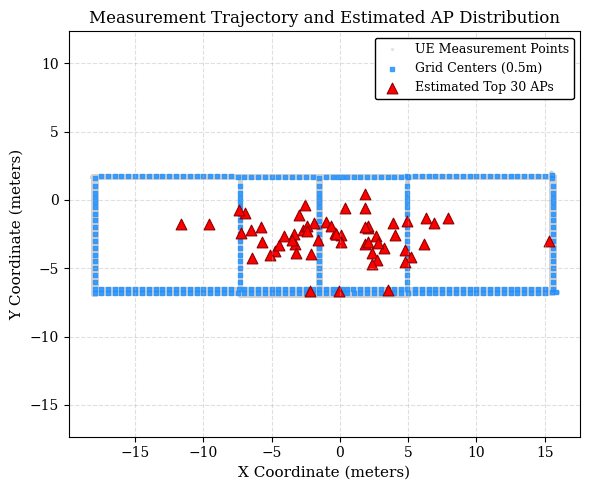

In [12]:
# ==========================================
# 1. Estimate AP Locations for Visualization (Centroid Method)
# ==========================================
# The WiLoc dataset does not provide actual AP positions. For visualization purposes only,
# we estimate AP locations by taking the centroid of all User Equipment (UE) measurements
# where a specific AP was heard. These estimated positions are NOT used by the machine learning models.
print("Estimating physical locations of the Top 30 APs...")

ap_estimates = []
for ap_id in top_aps:
    # Filter data to all UE measurements where this specific AP was detected
    ap_data = df_top[df_top['AP'] == ap_id]

    # Estimate the AP location as the mean of the UE locations that heard it
    est_x = ap_data['X'].mean()
    est_y = ap_data['Y'].mean()
    ap_estimates.append([ap_id, est_x, est_y])

df_aps = pd.DataFrame(ap_estimates, columns=['AP', 'Est_X', 'Est_Y'])

# ==========================================
# 2. Plotting Style Formatting
# ==========================================
# Configure Matplotlib to produce figures with IEEE publication-quality styling.
# This includes setting font families, sizes, and legend properties.
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9

# Create a figure with a size appropriate for a typical building floorplan visualization.
plt.figure(figsize=(6, 5))

# ==========================================
# 3. Plotting the Data Points
# ==========================================
# Plot 1: UE Measurement Trajectory
# Displays the overall footprint of where measurements were taken, representing the 'floorplan'.
# A small marker size and low opacity show density without cluttering the plot.
plt.scatter(df['X'], df['Y'], c='lightgray', s=2, alpha=0.5, label='UE Measurement Points')

# Plot 2: Grid Centers (Target Labels for the Neural Network)
# Shows the discretized spatial grid. These points are the ground truth coordinates
# that the neural network is trained to predict.
plt.scatter(Y_data[:, 0], Y_data[:, 1], c='dodgerblue', s=8, alpha=0.8, marker='s', label=f'Grid Centers ({GRID_SIZE}m)')

# Plot 3: Estimated Top AP Locations
# Visualizes the estimated positions of the most frequently heard APs.
plt.scatter(df_aps['Est_X'], df_aps['Est_Y'], c='red', s=60, marker='^', edgecolor='darkred', linewidth=0.8, label='Estimated Top 30 APs')

# ==========================================
# 4. Finalizing and Saving the Plot
# ==========================================
# Add axis labels, a title, and ensure equal aspect ratio for accurate spatial representation.
plt.xlabel('X Coordinate (meters)')
plt.ylabel('Y Coordinate (meters)')
plt.title('Measurement Trajectory and Estimated AP Distribution')

# Ensure the aspect ratio is equal so the building floorplan isn't distorted.
plt.axis('equal')

# Configure the legend for clarity and add a grid for readability.
plt.legend(loc='best', framealpha=1.0, edgecolor='black')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout() # Adjust layout to prevent labels/titles from overlapping.

# Save the figure in various formats suitable (PDF, PNG).
plt.savefig('spatial_dataset_visualization.pdf', format='pdf', bbox_inches='tight')
plt.savefig('spatial_dataset_visualization.png', format='png', dpi=300, bbox_inches='tight')

print("Plot successfully generated and saved!")
plt.show()

# Proposed MLP: From-Scratch Implementation with Pure NumPy


--- Starting Pure NumPy Training ---
Epoch [001/1000] | Train MSE: 47.7020 | Val MSE: 81.6791, RMSE: 9.0377 m
Epoch [010/1000] | Train MSE: 1.3691 | Val MSE: 59.6479, RMSE: 7.7232 m
Epoch [020/1000] | Train MSE: 0.7647 | Val MSE: 42.5996, RMSE: 6.5268 m
Epoch [030/1000] | Train MSE: 0.4084 | Val MSE: 20.6210, RMSE: 4.5410 m
Epoch [040/1000] | Train MSE: 0.6275 | Val MSE: 3.1330, RMSE: 1.7700 m
Epoch [050/1000] | Train MSE: 0.4651 | Val MSE: 0.4066, RMSE: 0.6376 m
Epoch [060/1000] | Train MSE: 0.6606 | Val MSE: 0.3480, RMSE: 0.5899 m
Epoch [070/1000] | Train MSE: 0.4147 | Val MSE: 0.2263, RMSE: 0.4758 m
Epoch [080/1000] | Train MSE: 0.4043 | Val MSE: 0.2915, RMSE: 0.5399 m
Epoch [090/1000] | Train MSE: 1.0098 | Val MSE: 0.1866, RMSE: 0.4320 m
Epoch [100/1000] | Train MSE: 0.3742 | Val MSE: 0.3408, RMSE: 0.5838 m
Epoch [110/1000] | Train MSE: 0.7823 | Val MSE: 0.2043, RMSE: 0.4519 m
Epoch [120/1000] | Train MSE: 0.2444 | Val MSE: 0.1830, RMSE: 0.4277 m
Epoch [130/1000] | Train MSE: 0.88

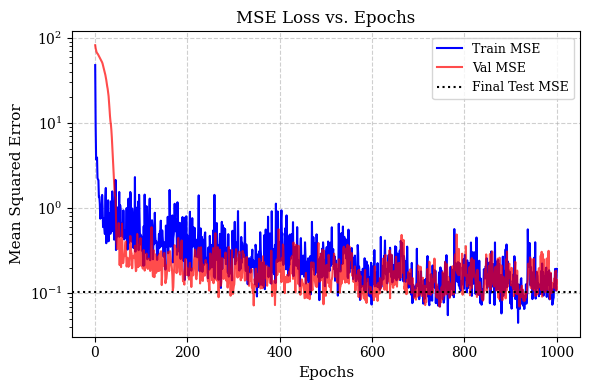

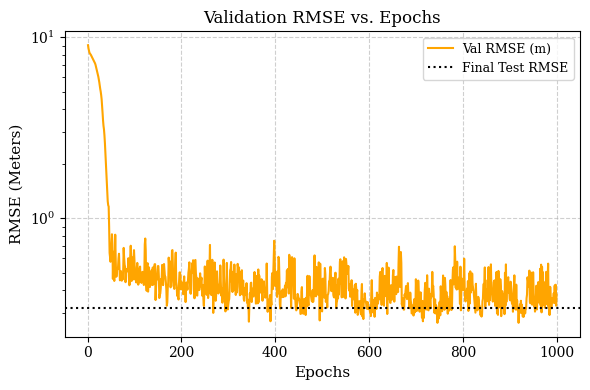

In [13]:
np.random.seed(42) # For reproducible results

# ==========================================
# 1. Hyperparameters & Setup
# ==========================================
EPOCHS = 1000       # Number of training iterations
LEARNING_RATE = 0.01 # Learning rate for optimizer
BATCH_SIZE = 128    # Number of samples per gradient update

# ==========================================
# 2. Layer Definitions (Pure NumPy)
# ==========================================
class Linear:
    def __init__(self, in_features, out_features):
        # Kaiming He Initialization for ReLU networks: helps prevent vanishing/exploding gradients
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2. / in_features)
        self.b = np.zeros((1, out_features)) # Biases initialized to zero
        self.dW = np.zeros_like(self.W)     # Gradients for weights
        self.db = np.zeros_like(self.b)     # Gradients for biases
        self.x = None                       # Store input for backward pass

    def forward(self, x, training=True):
        self.x = x
        return np.dot(x, self.W) + self.b # Linear transformation

    def backward(self, dout):
        self.dW = np.dot(self.x.T, dout) # Calculate weight gradients
        self.db = np.sum(dout, axis=0, keepdims=True) # Calculate bias gradients
        return np.dot(dout, self.W.T) # Propagate gradients backward

class ReLU:
    def __init__(self):
        self.x = None # Store input for backward pass

    def forward(self, x, training=True):
        self.x = x
        return np.maximum(0, x) # Element-wise ReLU activation

    def backward(self, dout):
        return dout * (self.x > 0) # Gradient for ReLU

class Dropout:
    def __init__(self, p=0.2):
        self.p = p     # Dropout probability
        self.mask = None # Mask for dropped units

    def forward(self, x, training=True):
        if training:
            # Randomly set some activations to zero during training
            self.mask = (np.random.rand(*x.shape) > self.p) / (1.0 - self.p)
            return x * self.mask
        return x # No dropout during inference

    def backward(self, dout):
        return dout * self.mask # Apply mask to gradients

class BatchNorm1d:
    def __init__(self, num_features, momentum=0.1, eps=1e-5):
        self.gamma = np.ones((1, num_features))   # Scale parameter
        self.beta = np.zeros((1, num_features))  # Shift parameter
        self.dgamma = np.zeros_like(self.gamma)
        self.dbeta = np.zeros_like(self.beta)

        self.eps = eps                          # Small constant for numerical stability
        self.momentum = momentum                # For updating running mean/variance
        self.running_mean = np.zeros((1, num_features))
        self.running_var = np.ones((1, num_features))

        self.cache = None # Store intermediate values for backward pass

    def forward(self, x, training=True):
        if training:
            mu = np.mean(x, axis=0, keepdims=True)  # Batch mean
            var = np.var(x, axis=0, keepdims=True)  # Batch variance

            # Update running statistics for inference
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mu
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var

            x_norm = (x - mu) / np.sqrt(var + self.eps) # Normalize batch
            self.cache = (x, x_norm, mu, var)
        else:
            # Use running statistics for inference
            x_norm = (x - self.running_mean) / np.sqrt(self.running_var + self.eps)

        return self.gamma * x_norm + self.beta # Scale and shift normalized output

    def backward(self, dout):
        x, x_norm, mu, var = self.cache
        N = x.shape[0]

        self.dgamma = np.sum(dout * x_norm, axis=0, keepdims=True) # Gamma gradient
        self.dbeta = np.sum(dout, axis=0, keepdims=True)           # Beta gradient

        dx_norm = dout * self.gamma
        dvar = np.sum(dx_norm * (x - mu) * -0.5 * (var + self.eps)**(-1.5), axis=0, keepdims=True)
        dmu = np.sum(dx_norm * -1.0 / np.sqrt(var + self.eps), axis=0, keepdims=True) + dvar * np.mean(-2.0 * (x - mu), axis=0, keepdims=True)

        dx = (dx_norm / np.sqrt(var + self.eps)) + (dvar * 2.0 * (x - mu) / N) + (dmu / N) # Propagate gradients
        return dx

# ==========================================
# 3. Model & Optimizer Definitions
# ==========================================
class NumPyMLP:
    def __init__(self, input_dim):
        # Define the network architecture (layers and their order)
        self.layers = [
            Linear(input_dim, 1024), BatchNorm1d(1024), ReLU(), Dropout(0.1),
            Linear(1024, 512), BatchNorm1d(512), ReLU(), Dropout(0.1),
            Linear(512, 256), BatchNorm1d(256), ReLU(),
            Linear(256, 2) # Output layer for 2D coordinates (X, Y)
        ]

    def forward(self, x, training=True):
        out = x
        for layer in self.layers:
            out = layer.forward(out, training=training) # Pass through layers sequentially
        return out

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout) # Backpropagate gradients through layers

    def get_params_and_grads(self):
        params, grads = [], []
        for layer in self.layers:
            if hasattr(layer, 'W'): # For Linear layers
                params.extend([layer.W, layer.b])
                grads.extend([layer.dW, layer.db])
            elif hasattr(layer, 'gamma'): # For BatchNorm layers
                params.extend([layer.gamma, layer.beta])
                grads.extend([layer.dgamma, layer.dbeta])
        return params, grads

class AdamOptimizer:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params # Model parameters to optimize
        self.lr = lr         # Learning rate
        self.beta1, self.beta2, self.eps = beta1, beta2, eps
        self.m = [np.zeros_like(p) for p in self.params] # First moment estimates (momentum)
        self.v = [np.zeros_like(p) for p in self.params] # Second moment estimates (RMSprop)
        self.t = 0           # Time step

    def step(self, grads):
        self.t += 1
        for i, (param, grad) in enumerate(zip(self.params, grads)):
            # Update biased first and second moment estimates
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (grad ** 2)

            # Bias-correction for first and second moment estimates
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            # Update parameters
            param -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

# MSE Loss function
def mse_loss(preds, targets):
    N = preds.shape[0]
    loss = np.mean((preds - targets) ** 2) # Mean Squared Error
    grad = 2.0 * (preds - targets) / N     # Gradient of MSE loss
    return loss, grad

# Batch generator
def get_batches(X, y, batch_size, shuffle=True):
    N = X.shape[0]
    indices = np.arange(N)
    if shuffle:
        np.random.shuffle(indices) # Shuffle data for training
    for start_idx in range(0, N, batch_size):
        end_idx = min(start_idx + batch_size, N)
        batch_idx = indices[start_idx:end_idx]
        yield X[batch_idx], y[batch_idx]

# ==========================================
# 4. Initialization
# ==========================================
# Assuming X_train, y_train, X_val, y_val, X_test, y_test are already defined and scaled
input_dimension = X_train.shape[1] # Input features dimension
model = NumPyMLP(input_dim=input_dimension) # Initialize the MLP model

# Extract reference to parameters for the optimizer
params, _ = model.get_params_and_grads()
optimizer = AdamOptimizer(params, lr=LEARNING_RATE) # Initialize Adam optimizer

history = { # To store training progress
    'train_mse': [], 'val_mse': [], 'val_rmse': []
}

print("\n--- Starting Pure NumPy Training ---")

# ==========================================
# 5. Training Loop
# ==========================================
for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    train_loss = 0.0
    total_train = 0

    for batch_X, batch_y in get_batches(X_train, y_train, BATCH_SIZE, shuffle=True):
        # Forward pass: compute predictions
        predictions = model.forward(batch_X, training=True)

        # Calculate loss and gradients at output
        loss, dout = mse_loss(predictions, batch_y)
        train_loss += loss * batch_X.shape[0]
        total_train += batch_X.shape[0]

        # Backward pass: compute gradients for all layers
        model.backward(dout)

        # Optimizer step: update model parameters
        _, grads = model.get_params_and_grads()
        optimizer.step(grads)

    avg_train_loss = train_loss / total_train

    # --- VALIDATION PHASE ---
    val_loss = 0.0
    total_val = 0

    for batch_X, batch_y in get_batches(X_val, y_val, BATCH_SIZE, shuffle=False):
        predictions = model.forward(batch_X, training=False) # No dropout during validation
        loss, _ = mse_loss(predictions, batch_y)
        val_loss += loss * batch_X.shape[0]
        total_val += batch_X.shape[0]

    avg_val_loss = val_loss / total_val
    avg_val_rmse = np.sqrt(avg_val_loss)

    # Save to history
    history['train_mse'].append(avg_train_loss)
    history['val_mse'].append(avg_val_loss)
    history['val_rmse'].append(avg_val_rmse)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
              f"Train MSE: {avg_train_loss:.4f} | "
              f"Val MSE: {avg_val_loss:.4f}, RMSE: {avg_val_rmse:.4f} m")

print("\nTraining Complete!")

# ==========================================
# 6. Final Unbiased Test Evaluation
# ==========================================
print("\n--- Running Final Test Set Evaluation ---")
test_loss = 0.0
total_test = 0

for batch_X, batch_y in get_batches(X_test, y_test, BATCH_SIZE, shuffle=False):
    predictions = model.forward(batch_X, training=False) # No dropout during testing
    loss, _ = mse_loss(predictions, batch_y)
    test_loss += loss * batch_X.shape[0]
    total_test += batch_X.shape[0]

final_test_loss = test_loss / total_test
final_test_rmse = np.sqrt(final_test_loss)

print(f"FINAL TEST RESULTS:")
print(f"Test MSE:  {final_test_loss:.4f}")
print(f"Test RMSE: {final_test_rmse:.4f} meters")

# ==========================================
# 7. Plotting Results (Separate Figures)
# ==========================================
print("\n--- Generating Performance Plots ---")

epochs_range = range(1, EPOCHS + 1)

# ------------------------------------------
# Plot 1: Train vs Validation MSE
# ------------------------------------------
plt.figure(figsize=(6, 4))
plt.semilogy(epochs_range, history['train_mse'], label='Train MSE', color='blue')
plt.semilogy(epochs_range, history['val_mse'], label='Val MSE', color='red', alpha=0.7)
plt.axhline(y=final_test_loss, color='black', linestyle=':', label='Final Test MSE')
plt.title('MSE Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('mlp_mse_loss.pdf', format='pdf', bbox_inches='tight')
plt.savefig('mlp_mse_loss.png', format='png', dpi=300, bbox_inches='tight')

# ------------------------------------------
# Plot 2: Validation RMSE
# ------------------------------------------
plt.figure(figsize=(6, 4))
plt.semilogy(epochs_range, history['val_rmse'], label='Val RMSE (m)', color='orange')
plt.axhline(y=final_test_rmse, color='black', linestyle=':', label='Final Test RMSE')
plt.title('Validation RMSE vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('RMSE (Meters)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('mlp_val_rmse.pdf', format='pdf', bbox_inches='tight')
plt.savefig('mlp_val_rmse.png', format='png', dpi=300, bbox_inches='tight')

print("Saved individual plots as PDF and PNG files.")
plt.show()


--- Generating Error Vector Map ---
Error Vector Map successfully generated and saved!


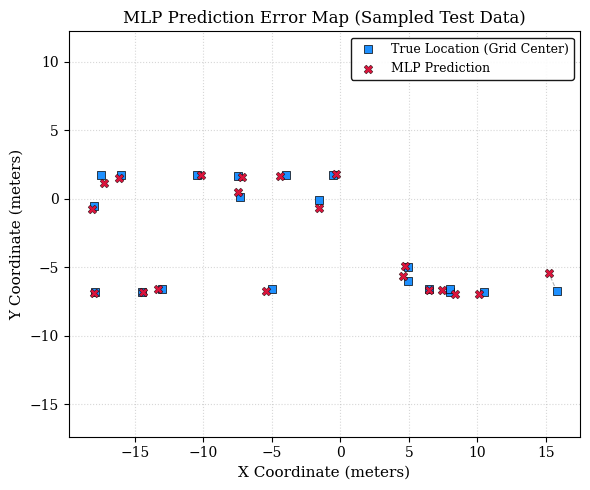

In [14]:
# ==========================================
# 8. Visualizing Predictions (Error Vector Map)
# ==========================================
print("\n--- Generating Error Vector Map ---")

# 1. Collect all predictions for the test set
y_pred_list = []
y_true_list = []

for batch_X, batch_y in get_batches(X_test, y_test, BATCH_SIZE, shuffle=False):
    preds = model.forward(batch_X, training=False)
    y_pred_list.append(preds)
    y_true_list.append(batch_y)

# Stack them into full numpy arrays
y_pred_all = np.vstack(y_pred_list)
y_true_all = np.vstack(y_true_list)

# 2. Sample a subset of points to avoid a cluttered plot
# Plotting 50-60 points usually looks best for a standard conference column width
num_viz_samples = 20
np.random.seed(42) # For reproducible plots
sample_indices = np.random.choice(len(y_true_all), size=num_viz_samples, replace=False)

y_true_sample = y_true_all[sample_indices]
y_pred_sample = y_pred_all[sample_indices]

# 3. IEEE Style Formatting
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9

plt.figure(figsize=(6, 5))

# 4. Plot the error lines (connecting true to predicted)
for i in range(num_viz_samples):
    # Plot a dashed line representing the error vector
    plt.plot([y_true_sample[i, 0], y_pred_sample[i, 0]],
             [y_true_sample[i, 1], y_pred_sample[i, 1]],
             color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# 5. Plot the actual points
# True positions (Ground Truth)
plt.scatter(y_true_sample[:, 0], y_true_sample[:, 1],
            c='dodgerblue', marker='s', s=30, edgecolor='black', linewidth=0.5,
            label='True Location (Grid Center)', zorder=3)

# Predicted positions (MLP Output)
plt.scatter(y_pred_sample[:, 0], y_pred_sample[:, 1],
            c='crimson', marker='X', s=40, edgecolor='black', linewidth=0.3,
            label='MLP Prediction', zorder=3)

# 6. Finalizing and Saving
plt.xlabel('X Coordinate (meters)')
plt.ylabel('Y Coordinate (meters)')
plt.title('MLP Prediction Error Map (Sampled Test Data)')

# Ensure equal aspect ratio so distance looks visually accurate
plt.axis('equal')

plt.legend(loc='best', framealpha=0.9, edgecolor='black')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

plt.savefig('mlp_error_map.pdf', format='pdf', bbox_inches='tight')
plt.savefig('mlp_error_map.png', format='png', dpi=300, bbox_inches='tight')
save_tikz("mlp_error_map.tex")

print("Error Vector Map successfully generated and saved!")
plt.show()

# Baselines

In [16]:
np.random.seed(42) # For reproducible results across baseline models
print("--- Training Traditional ML Baselines ---")

# Define a consistent evaluation function for all baseline models
def evaluate_baseline(model_name, y_true, y_pred):
    """
    Evaluates a regression model using Mean Squared Error (MSE) and Root Mean Squared Error (RMSE).
    Prints the results for comparison.
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"\n{model_name} Results:")
    print(f"Test MSE:  {mse:.4f}")
    print(f"Test RMSE: {rmse:.4f} meters")

    return rmse

# ==========================================
# 1. k-Nearest Neighbors (k-NN) Regressor
# ==========================================
# k-NN is a simple, non-parametric method. It predicts based on the average
# of its 'k' nearest neighbors in the feature space.
# We use k=3 and 'distance' weights, giving more influence to closer neighbors.
knn = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)
evaluate_baseline("1. k-Nearest Neighbors (k-NN)", y_test, knn_preds)

# ==========================================
# 2. Random Forest Regressor
# ==========================================
# An ensemble method that builds multiple decision trees and merges their predictions
# to improve accuracy and control overfitting.
# n_estimators=100 specifies 100 trees, and n_jobs=-1 uses all available CPU cores.
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
evaluate_baseline("2. Random Forest Regressor", y_test, rf_preds)

# ==========================================
# 3. Ridge Regression (Linear Model Baseline)
# ==========================================
# A linear regression model with L2 regularization, useful as a robust linear baseline.
# The 'alpha' parameter controls the strength of the regularization.
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_preds = ridge.predict(X_test_scaled)
evaluate_baseline("3. Ridge Regression", y_test, ridge_preds)

# ==========================================
# 4. Support Vector Regressor (SVR) with RBF Kernel
# ==========================================
# SVR extends Support Vector Machines to regression tasks. The RBF kernel allows
# it to capture non-linear relationships. MultiOutputRegressor is used because SVR
# inherently handles only single-output regression.
print("\nTraining SVM")
svm_base = SVR(kernel='rbf', C=10.0, epsilon=0.01)
multi_svm = MultiOutputRegressor(svm_base, n_jobs=-1) # n_jobs=-1 trains X and Y concurrently
multi_svm.fit(X_train_scaled, y_train)
svm_preds = multi_svm.predict(X_test_scaled)
evaluate_baseline("4. Support Vector Regressor (RBF Kernel)", y_test, svm_preds)

# ==========================================
# 5. Decision Tree Regressor
# ==========================================
# A single decision tree. This serves as a simpler comparison to the Random Forest,
# highlighting the benefit of ensembling multiple trees.
print("\nTraining Decision Tree...")
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_preds = dt.predict(X_test_scaled)
evaluate_baseline("5. Decision Tree Regressor", y_test, dt_preds)


# ==========================================
# Compare with the Proposed MLP Model
# ==========================================
# This section provides a direct comparison with the performance of the
# custom-built MLP, whose results were obtained from the previous cell.
print("\n==========================================")
print(f"Proposed MLP Test RMSE: {final_test_rmse:.4f} meters")
print(f"Proposed MLP Test MSE:  {final_test_loss:.4f}")
print("==========================================")

--- Training Traditional ML Baselines ---

1. k-Nearest Neighbors (k-NN) Results:
Test MSE:  0.2625
Test RMSE: 0.5124 meters

2. Random Forest Regressor Results:
Test MSE:  3.3120
Test RMSE: 1.8199 meters

3. Ridge Regression Results:
Test MSE:  3.3221
Test RMSE: 1.8227 meters

Training SVM

4. Support Vector Regressor (RBF Kernel) Results:
Test MSE:  1.7118
Test RMSE: 1.3084 meters

Training Decision Tree...

5. Decision Tree Regressor Results:
Test MSE:  4.2985
Test RMSE: 2.0733 meters

Proposed MLP Test RMSE: 0.3212 meters
Proposed MLP Test MSE:  0.1032


# Results vs number of APs

In [17]:
# We retrain the proposed MLP and baseline models by adjusting the number of APs (MAX_APS)
# in previous cells and setting the GRID_SIZE to 0.5 m. The following RMSE Test values
# are collected for different numbers of APs and are prepared for plotting.
N_AP = np.array([10, 20, 30, 40, 50, 60])
MLP_RMSE_test = np.array([0.7114, 0.6347, 0.5296, 0.4843, 0.4009, 0.3212])
KNN_RMSE_test = np.array([0.7757, 0.7677, 0.5707, 0.6026, 0.5166, 0.5124])
SVM_RMSE_test = np.array([2.4713, 2.3018, 2.4605, 2.1317, 1.4503, 1.3084])
RF_RMSE_test = np.array([2.0282, 1.8463, 1.8973, 1.9702, 1.8467, 1.8199])
RR_RMSE_test = np.array([6.6771, 13.6949, 18.6760, 9.6700, 2.0608, 1.8226])

Plots successfully generated and saved as 'rmse_vs_aps.pdf' and 'rmse_vs_aps.png'.


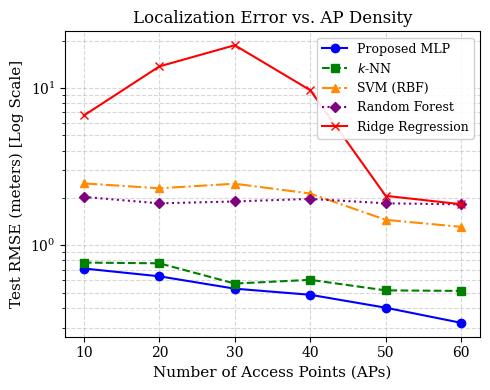

In [18]:
# ==========================================
# 2. Set Style Formatting Parameters
# ==========================================
# Use standard serif fonts
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9

# Create a figure sized appropriately for a standard IEEE column (approx 3.5 inches wide)
# Here we use a slightly larger ratio that scales down perfectly
plt.figure(figsize=(5, 4))

# ==========================================
# 3. Plotting the Curves
# ==========================================
# We use a logarithmic y-axis to handle the massive 18m spike in Ridge Regression
# while still showing the sub-meter differences between MLP and KNN.
plt.semilogy(N_AP, MLP_RMSE_test, marker='o', linestyle='-', color='blue', linewidth=1.5, markersize=6, label='Proposed MLP')
plt.semilogy(N_AP, KNN_RMSE_test, marker='s', linestyle='--', color='green', linewidth=1.5, markersize=6, label='$k$-NN')
plt.semilogy(N_AP, SVM_RMSE_test, marker='^', linestyle='-.', color='darkorange', linewidth=1.5, markersize=6, label='SVM (RBF)')
plt.semilogy(N_AP, RF_RMSE_test, marker='D', linestyle=':', color='purple', linewidth=1.5, markersize=5, label='Random Forest')
plt.semilogy(N_AP, RR_RMSE_test, marker='x', linestyle='-', color='red', linewidth=1.5, markersize=6, label='Ridge Regression')

# ==========================================
# 4. Finalizing and Saving
# ==========================================
plt.xlabel('Number of Access Points (APs)')
plt.ylabel('Test RMSE (meters) [Log Scale]')
plt.title('Localization Error vs. AP Density')

# Set custom x-ticks to match the array exactly
plt.xticks(N_AP)

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(loc='best', framealpha=0.9)
plt.tight_layout()

# Save in high resolution for the paper
plt.savefig('rmse_vs_aps.pdf', format='pdf', bbox_inches='tight')
plt.savefig('rmse_vs_aps.png', format='png', dpi=300, bbox_inches='tight')
save_tikz("rmse_vs_aps.tex")

print("Plots successfully generated and saved as 'rmse_vs_aps.pdf' and 'rmse_vs_aps.png'.")
plt.show()

# Results vs Grid Size

In [19]:
# We retrain the proposed MLP and baseline models to test the robustness of the methods.
# Here, we fix the number of APs to 30 (MAX_APS = 30 in previous cells) and vary the GRID_SIZE.
# The following RMSE Test values are collected for different grid sizes and are prepared for plotting.
Grid_size_arr = np.array([0.1, 0.3, 0.5])
MLP_RMSE_test_g = np.array([0.6782, 0.6220, 0.5296])
KNN_RMSE_test_g = np.array([0.7767, 0.6860, 0.5707])
SVM_RMSE_test_g = np.array([2.5545, 2.4604, 2.4605])
RF_RMSE_test_g = np.array([0.8339, 0.7990, 0.7990])
RR_RMSE_test_g = np.array([4.9091, 6.9970, 6.9970])

Plots successfully generated and saved as 'rmse_vs_grid.pdf' and 'rmse_vs_grid.png'.


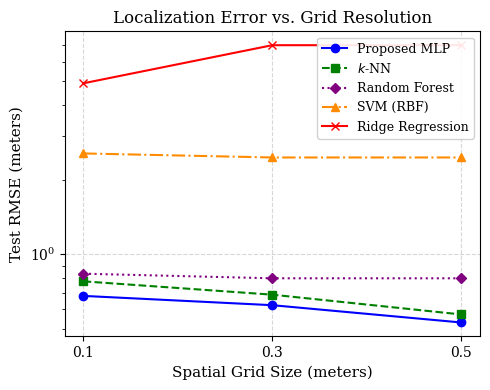

In [20]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# 2. Set Style Formatting Parameters
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9

plt.figure(figsize=(5, 4))

# ==========================================
# 3. Plotting the Curves
# ==========================================
plt.semilogy(Grid_size_arr, MLP_RMSE_test_g, marker='o', linestyle='-', color='blue', linewidth=1.5, markersize=6, label='Proposed MLP')
plt.semilogy(Grid_size_arr, KNN_RMSE_test_g, marker='s', linestyle='--', color='green', linewidth=1.5, markersize=6, label='$k$-NN')
plt.semilogy(Grid_size_arr, RF_RMSE_test_g, marker='D', linestyle=':', color='purple', linewidth=1.5, markersize=5, label='Random Forest')
plt.semilogy(Grid_size_arr, SVM_RMSE_test_g, marker='^', linestyle='-.', color='darkorange', linewidth=1.5, markersize=6, label='SVM (RBF)')
plt.semilogy(Grid_size_arr, RR_RMSE_test_g, marker='x', linestyle='-', color='red', linewidth=1.5, markersize=6, label='Ridge Regression')

# ==========================================
# 4. Finalizing and Saving
# ==========================================
plt.xlabel('Spatial Grid Size (meters)')
plt.ylabel('Test RMSE (meters)')
plt.title('Localization Error vs. Grid Resolution')

# Ensure the x-axis ticks match the specific grid sizes exactly
plt.xticks(Grid_size_arr)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', framealpha=0.9)
plt.tight_layout()

# Save in high resolution for the paper
plt.savefig('rmse_vs_grid.pdf', format='pdf', bbox_inches='tight')
plt.savefig('rmse_vs_grid.png', format='png', dpi=300, bbox_inches='tight')
save_tikz("rmse_vs_grid.tex")

print("Plots successfully generated and saved as 'rmse_vs_grid.pdf' and 'rmse_vs_grid.png'.")
plt.show()